In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
import jax
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, SetupKLConfig, SignalGrid, get_builders, plot_arrays, map_signal

jax.config.update("jax_enable_x64", True)

jwst not installed. Some JWST functions will not work.
shapely not installed. Some JWST functions will not work.


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def latest_model_file(directory):
    import os
    import re

    max_file = None
    max_it = -1
    for filename in os.listdir(directory + '/files'):
        match = re.compile(r'(\d+)_pre\.yml$').match(filename)
        if match:
            it = int(match.group(1))
            if it > max_it:
                max_it = it
                max_file = filename

    return directory + f'/files/{max_file}'



def box_markers(cfg, ps_map, grid, it):
    import numpy as np
    from aim_resolve import draw_boxes

    px, py = np.argwhere(ps_map == 1).T
    ps_mrk = dict(x=px, y=py, s=10, c='white', marker='+')
    box_map = draw_boxes(cfg.sections, grid, it)
    ox, oy = np.argwhere(box_map == 1).T
    oj_mrk = dict(x=ox, y=oy, s=0.1, c='white', marker=',')
    
    return dict(ps_mrk=ps_mrk, oj_mrk=oj_mrk)

In [4]:
dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_2z_b'

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


eso_yml = latest_model_file(dir)
print('load:', eso_yml)

optim_cfg = OptimizeKLConfig.from_file((dir + '/files/base.yml', eso_yml), get_builders, 'total')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/data/eso_986-1137mhz.npz'


# obs = optim_cfg.instantiate_sec('data.0')
# space = SignalGrid.build(**optim_cfg.sections['grid_bg'])
# dirty = obs.dirty_image(space)
# print('dirty image shape:', dirty.shape)

sky_models = [sec for sec in optim_cfg.sections if sec.startswith('sky.')]
print('sky components:', sky_models)

sky_list, samples_list, sky_markers = [], [], []
for it,sec in enumerate(sky_models):
    sky_it = optim_cfg.instantiate_sec(sec)
    sky_list.append(sky_it)
    with open(dir + f'/opt/{it}_rec/last.pkl', "rb") as f:
        smp_it, *_ = pickle.load(f)
    samples_list.append(smp_it)

    if it == 0:
        sky_markers += [{}]
    else:
        setup_cfg = SetupKLConfig.from_file(eso_yml)
        sky_ps = sky_it.points[0]
        ps_map = map_signal(sky_ps.points.grid, sky_ps.grid)(np.ones(sky_ps.shape))
        sky_markers += [box_markers(setup_cfg, ps_map, sky_it.grid, it), ]

print('len sky_list:', len(sky_list))
print('len samples_list:', len(samples_list))
print('len sky_markers:', len(sky_markers))

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_2z_b/files/2_pre.yml
sky components: ['sky.0', 'sky.1', 'sky.2']
len sky_list: 3
len samples_list: 3
len sky_markers: 3


In [5]:
mf_rec = '4_rec_4f'
it = 3

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


opt_yml = f'{dir}/opt/{mf_rec}/opt.yml'
print('load:', opt_yml)

optim_cfg = OptimizeKLConfig.from_file(opt_yml, get_builders, 'major')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/data/eso_986-1137mhz.npz'
optim_cfg.sections[f'data.{it}']['fname'] = '/Users/rf/Development/data/eso_1356-1439mhz.npz'

sky_mf = optim_cfg.instantiate_sec(f'sky.{it}')
print(sky_mf.domain.tree.keys())

with open(f'{dir}/opt/{mf_rec}/last.pkl', "rb") as f:
    samples_mf, *_ = pickle.load(f)

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_2z_b/opt/4_rec_4f/opt.yml
dict_keys(['bg.3 i0 zeromode', 'bg.3 i0 fluctuations', 'bg.3 i0 xi', 'bg.3 i0 loglogavgslope', 'bg.3 i0 spectrum', 'bg.3 i0 flexibility', 'bg.3 i0 asperity', 'bg.3 dev xi', 'bg.3 dev sigma', 'bg.3 alpha mean', 'bg.3 alpha fluctuations', 'bg.3 alpha xi', 'bg.3 alpha loglogavgslope', 'bg.3 alpha spectrum', 'bg.3 alpha flexibility', 'bg.3 alpha asperity', 'p0.3 alpha ', 'p0.3 dev sigma', 'p0.3 dev xi', 'p0.3 i0 ', 'o0.3 i0 zeromode', 'o0.3 i0 fluctuations', 'o0.3 i0 xi', 'o0.3 i0 loglogavgslope', 'o0.3 i0 spectrum', 'o0.3 i0 flexibility', 'o0.3 i0 asperity', 'o0.3 dev xi', 'o0.3 dev sigma', 'o0.3 alpha mean', 'o0.3 alpha fluctuations', 'o0.3 alpha xi', 'o0.3 alpha loglogavgslope', 'o0.3 alpha spectrum', 'o0.3 alpha flexibility', 'o0.3 alpha asperity', 'o0.3 gm cov_x', 'o0.3 gm cov_y', 'o1.3 i0 zeromode', 'o1.3 i0 fluctuations', 'o1.3 i0 xi', 'o1.3 i0 loglogavgslope', 'o1.3 i0 spectrum'

In [6]:
plot_dict = dict(
    name = None,
    odir = None,
    cmap = 'inferno',
    cbar = False,
    ticks = 0,
)

In [7]:
sky_means, sky_stds = [], []
for sky, smp in zip(sky_list, samples_list):
    mean, std = smp.mean_and_std(sky)
    sky_means += [mean * CONV_FACTOR, ]
    sky_stds += [std * CONV_FACTOR, ]

print('len sky_means:', len(sky_means))
print('len sky_stds:', len(sky_stds))

len sky_means: 3
len sky_stds: 3


plotting ...


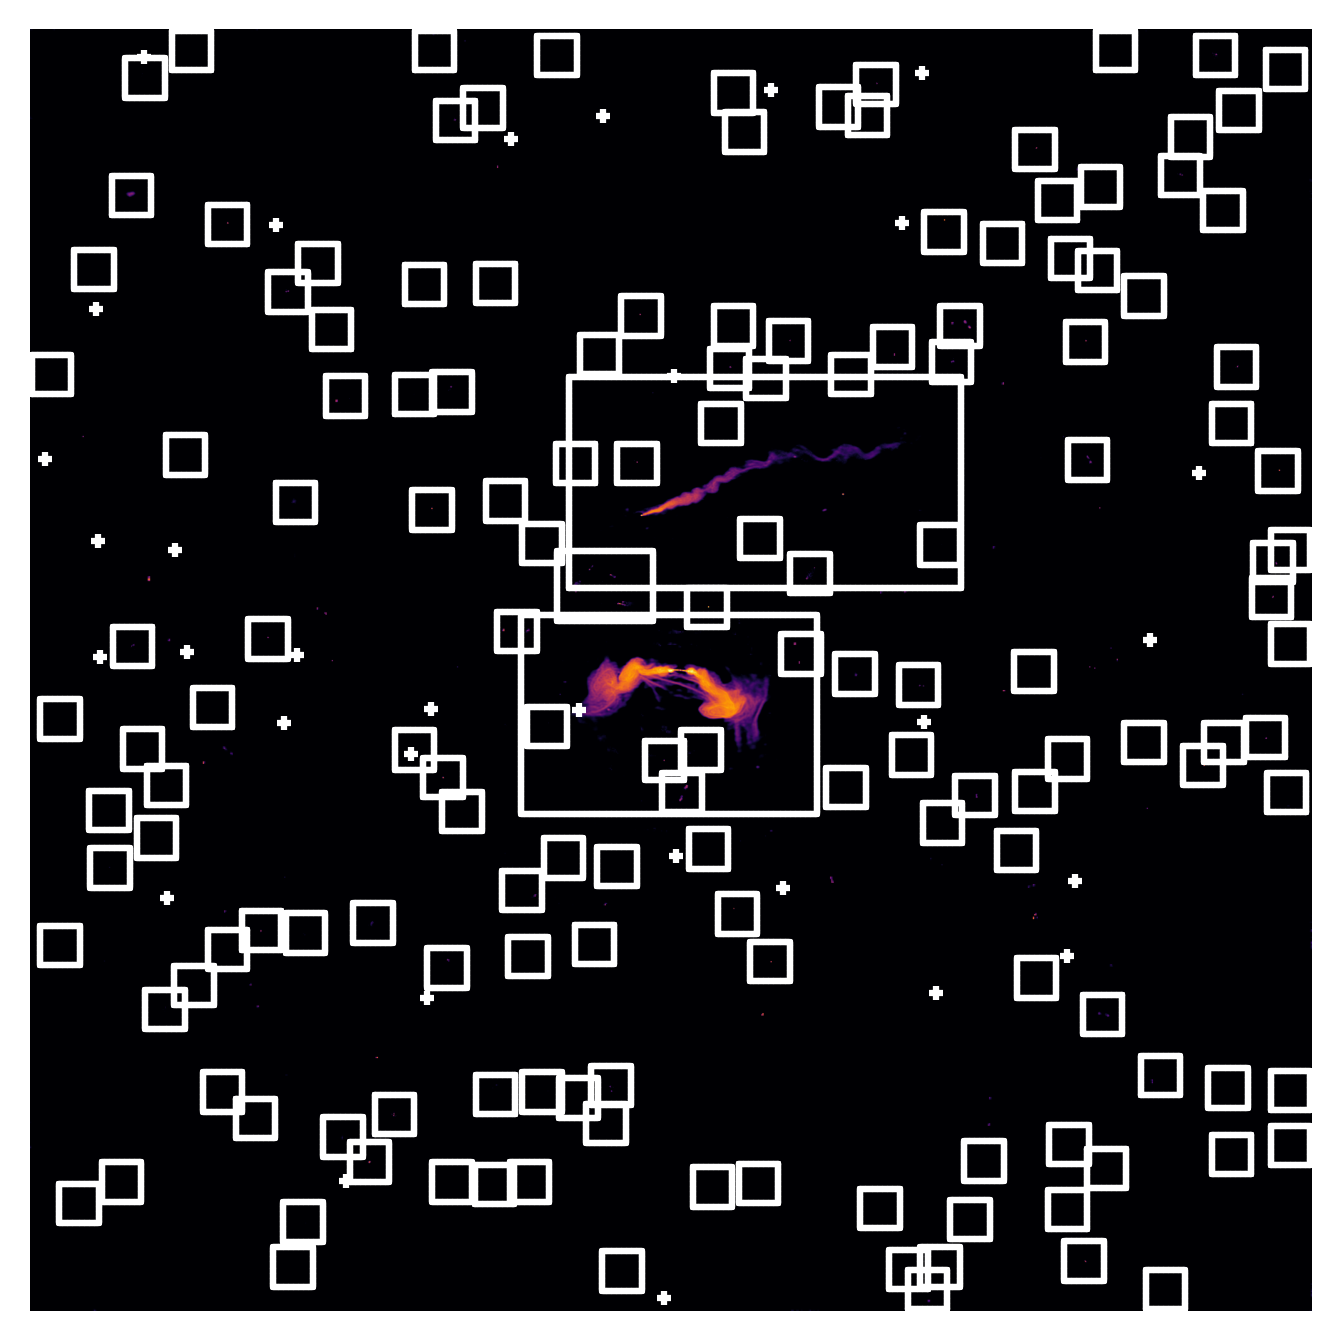

In [8]:
mdl_it = 3

array = sky_means[mdl_it-1]
plot_markers = sky_markers[mdl_it-1]

vmax = np.max(array)
vmin = 2e-3

def callback(fig, axes):
    fig.text(0.657, 0.09, 'Iteration 3', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    array, 
    marker=plot_markers,
    norm='log', 
    vmin=vmin, 
    vmax=vmax,
    # callback=callback,
    dpi=300,
    **plot_dict,
)

[5.5, 5.5, 11, 11]
plotting ...


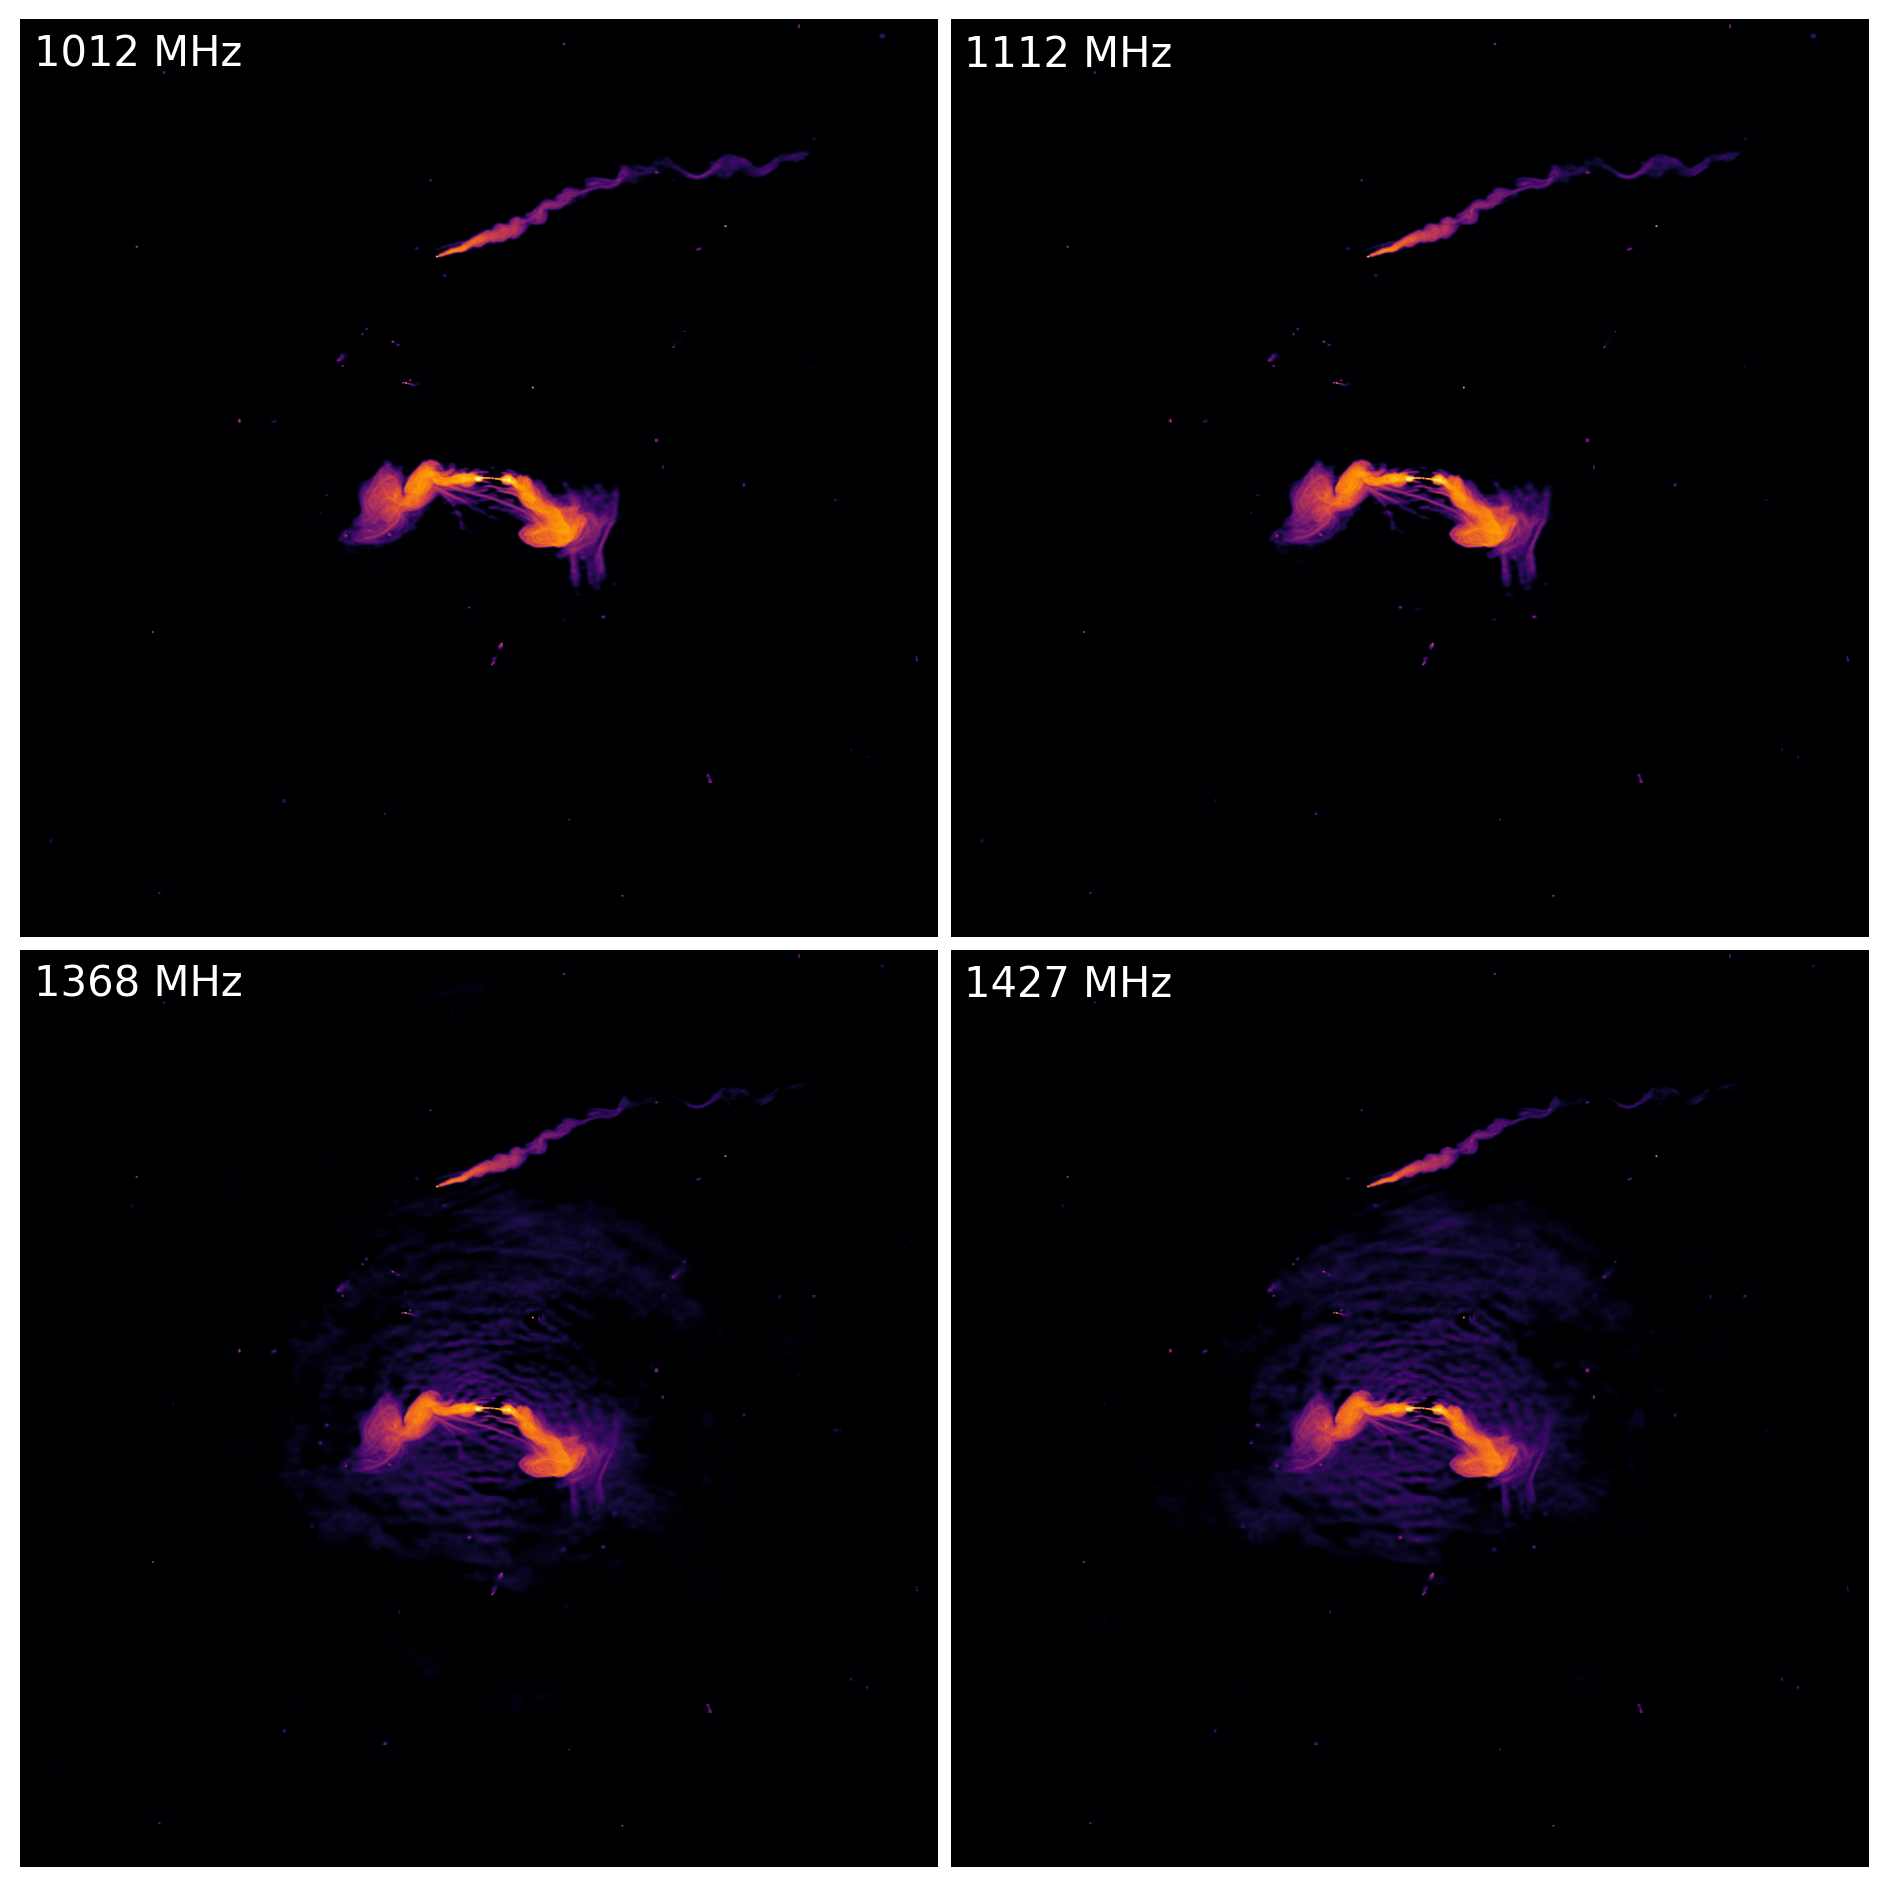

In [9]:
mdl = sky_mf
smp = samples_mf

sky_val = smp.mean(mdl) * CONV_FACTOR
grd = mdl.grid
sky_val = map_signal(grd, grd.update(space=grd.spc//2))(sky_val)

mmin = 2*[2e-3] + 2*[4e-3]
mmax = [5.5, 5.5, 11, 11]
print(mmax)

def callback(fig, axes):
    fig.text(0.045, 0.950, '1012 MHz', fontsize=15, c='white')
    fig.text(0.51, 0.950, '1112 MHz', fontsize=15, c='white')
    fig.text(0.045, 0.485, '1368 MHz', fontsize=15, c='white')
    fig.text(0.51, 0.485, '1427 MHz', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    sky_val, 
    rows=2,
    norm='log',
    vmin=mmin, 
    vmax=mmax, 
    grid_kwargs=dict(hspace=-0.71, wspace=-0.7, width_ratios=[1,1], height_ratios=[1,1]),
    callback=callback,
    dpi=200, 
    **plot_dict,
)

plotting ...


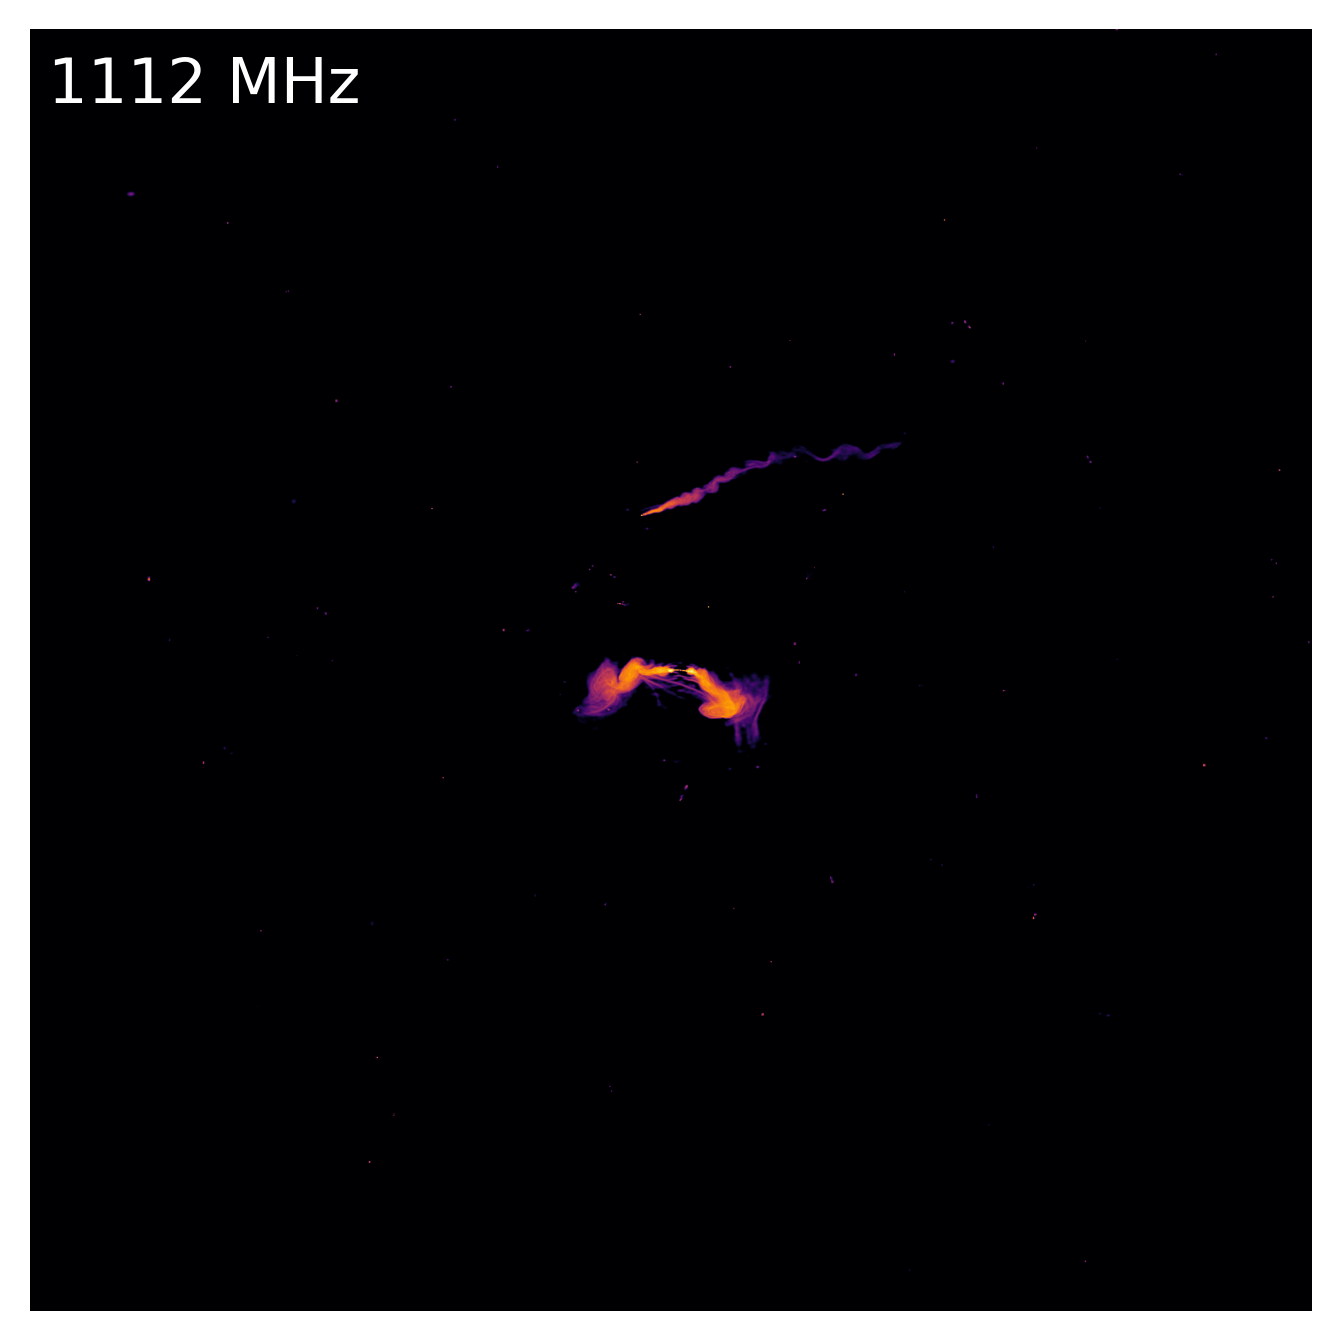

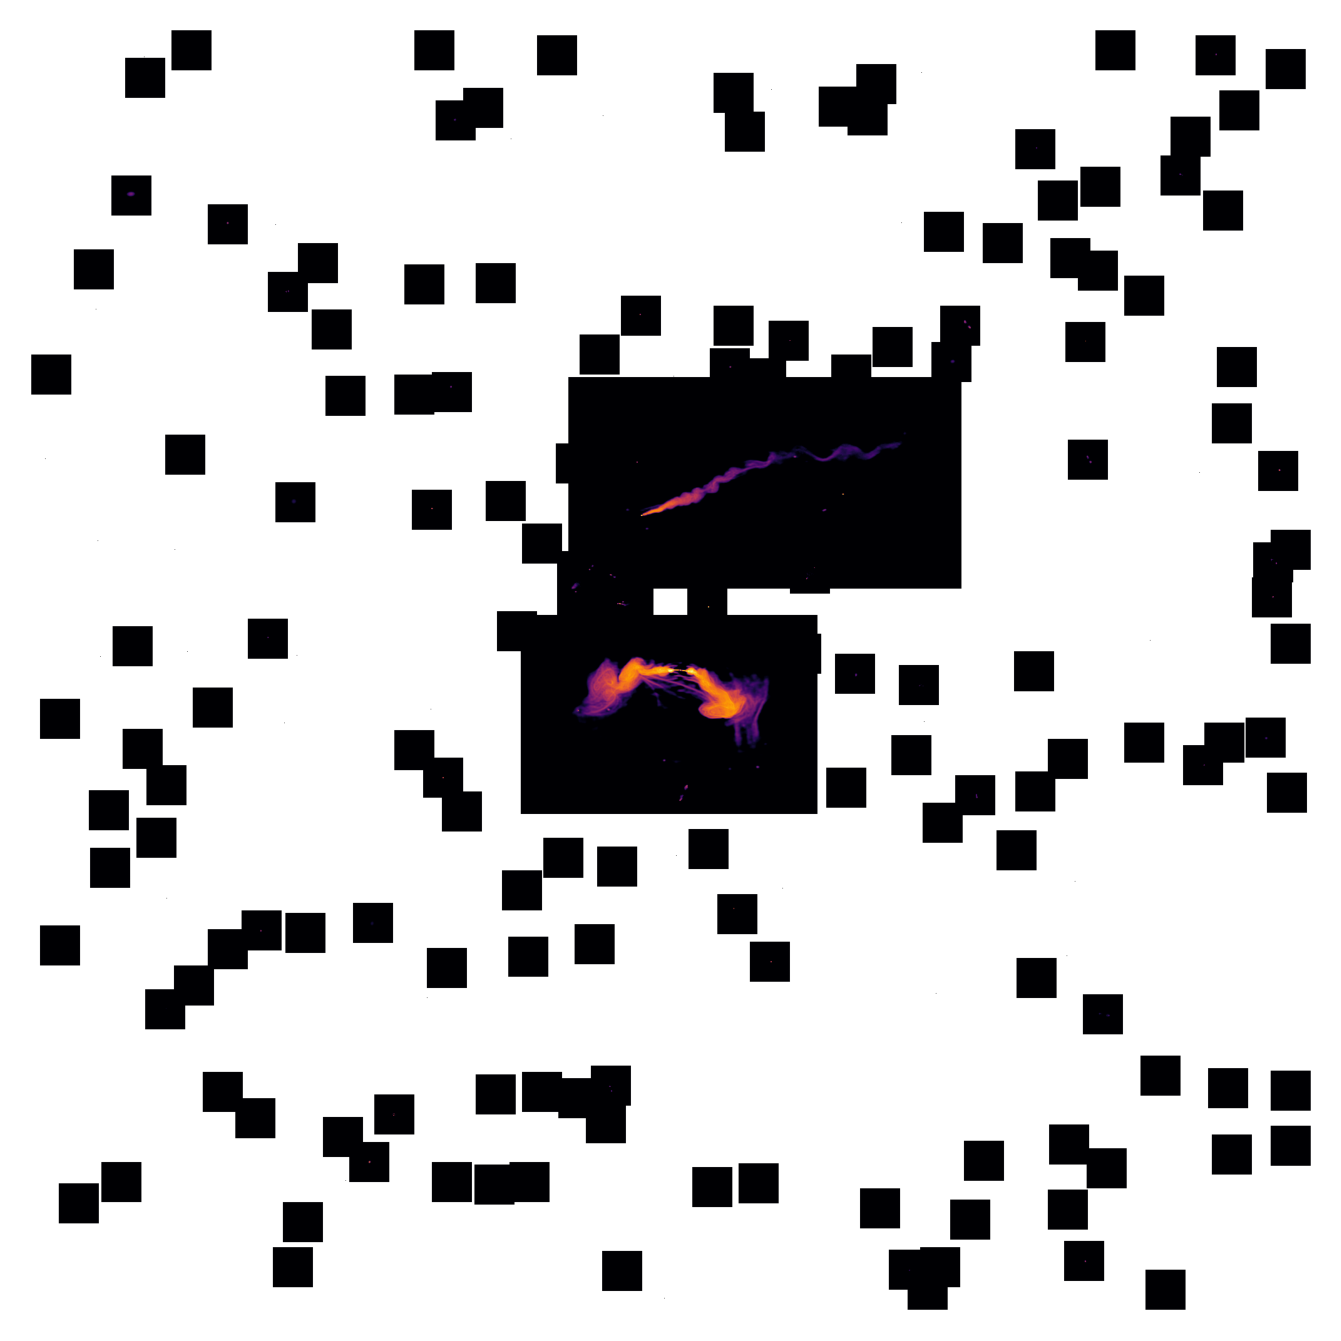

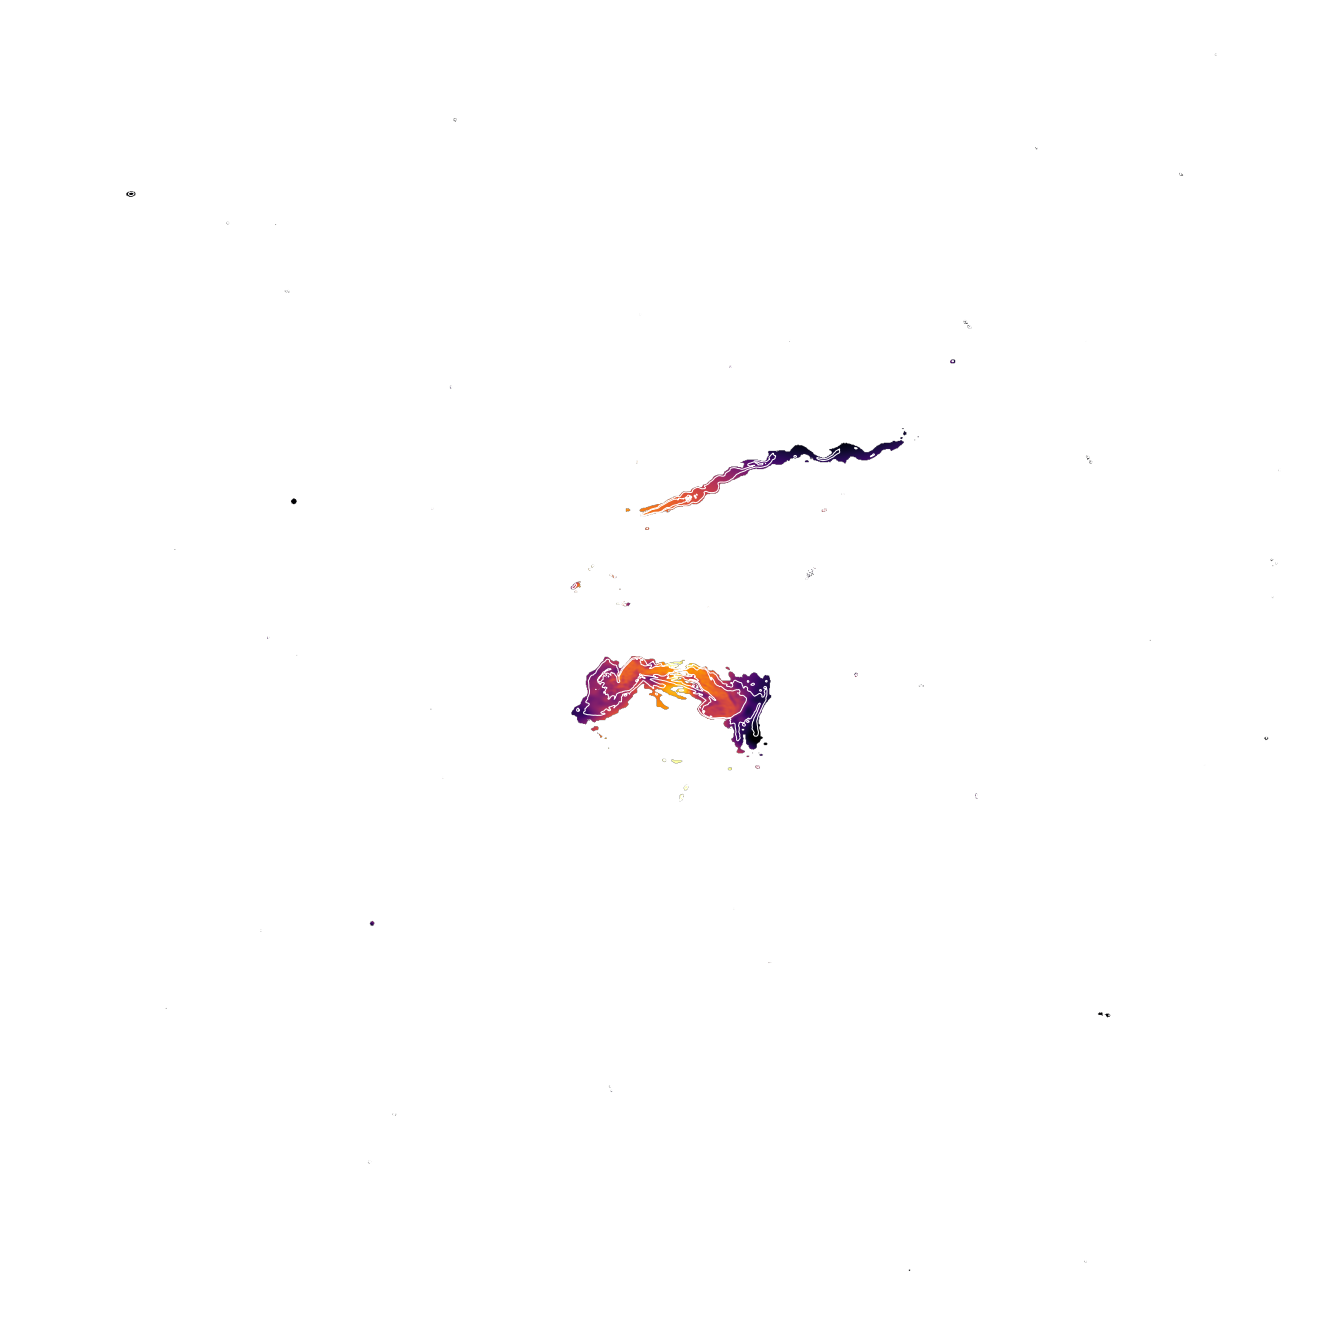

In [10]:
mdl = sky_mf
smp = samples_mf

sky_ref = smp.mean(mdl.ref_freq_model) * CONV_FACTOR
mmin = 2e-3
mmax = sky_ref.max()

sky_pot = smp.mean(mdl.points_and_objects.ref_freq_model) * CONV_FACTOR
alpha = smp.mean(mdl.points_and_objects.spectral_index)
alpha = np.where(sky_pot > mmin, alpha-2, np.nan)
amin = -3
amax = 1

contours = {'array': sky_ref, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.25}

def callback(fig, axes):
    fig.text(0.085, 0.90, '1112 MHz', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    sky_ref, 
    norm='log',
    vmin=mmin,
    vmax=mmax,
    dpi=300,
    callback=callback,
    **plot_dict,
)
plot_arrays(
    sky_pot, 
    norm='log',
    vmin=mmin, 
    vmax=mmax,
    dpi=300,
    **plot_dict,
)
plot_arrays(
    alpha, 
    norm='linear',
    vmin=amin,
    vmax=amax,
    dpi=300, 
    contour=contours,
    **plot_dict,
)

plotting ...


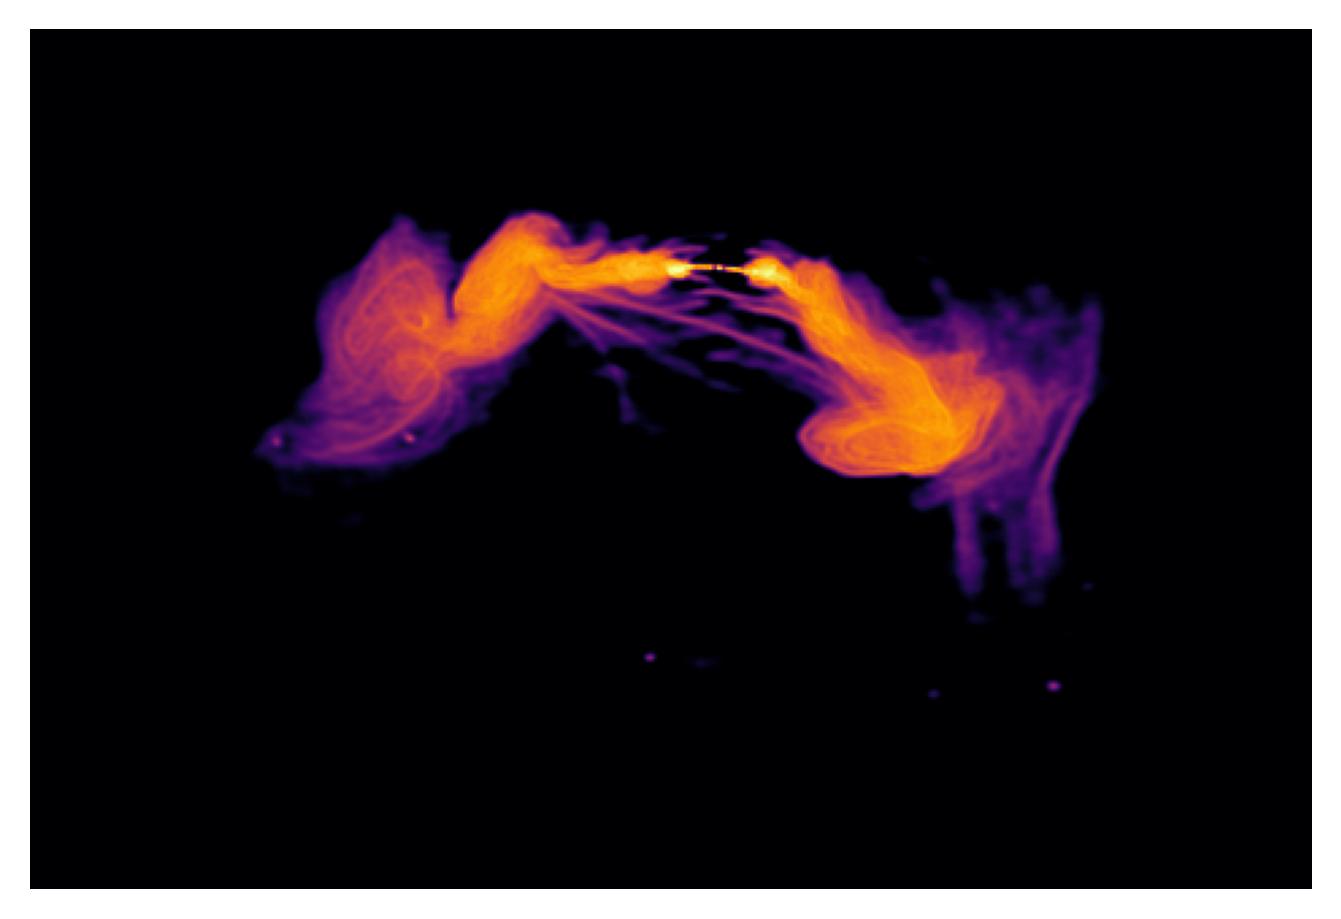

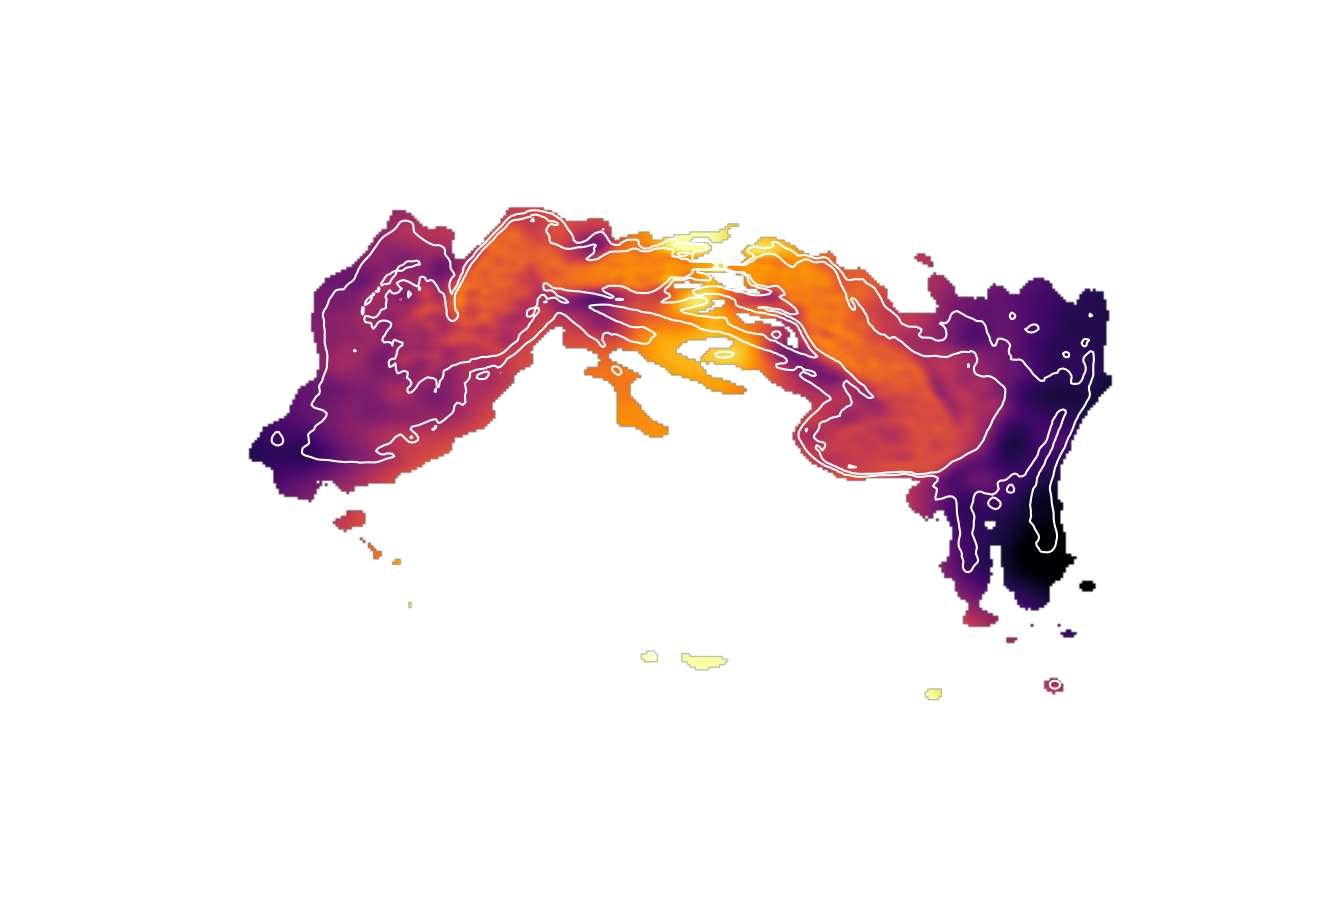

In [11]:
mdl = sky_mf.components[1]
smp = samples_mf

sky_ref = smp.mean(mdl.ref_freq_model) * CONV_FACTOR

alpha = smp.mean(mdl.spectral_index)
alpha = np.where(sky_ref > mmin, alpha-2, np.nan)

contours = {'array': sky_ref, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.5}

print('plotting ...')
plot_arrays(
    sky_ref, 
    norm='log',
    vmin=mmin,
    vmax=mmax,
    dpi=300,
    **plot_dict,
)
plot_arrays(
    alpha, 
    norm='linear',
    vmin=amin,
    vmax=amax,
    dpi=300, 
    contour=contours,
    **plot_dict,
)

plotting ...


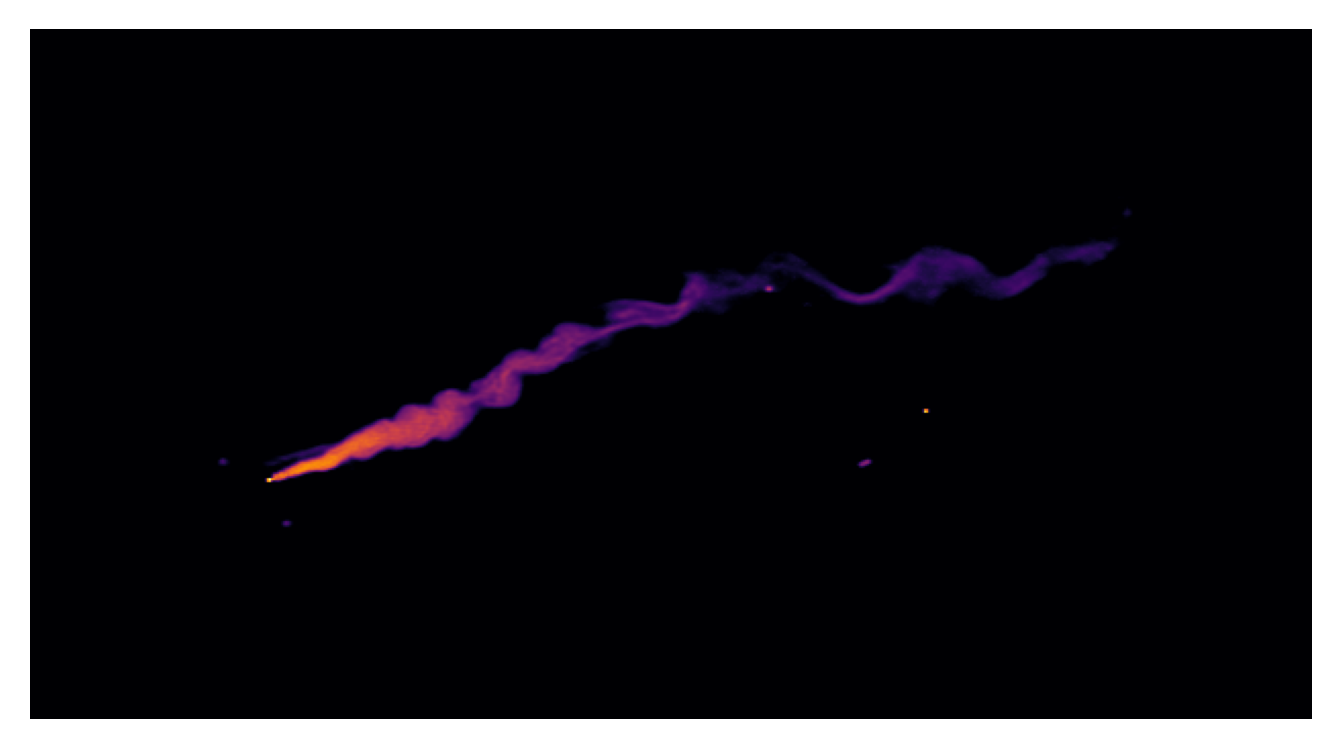

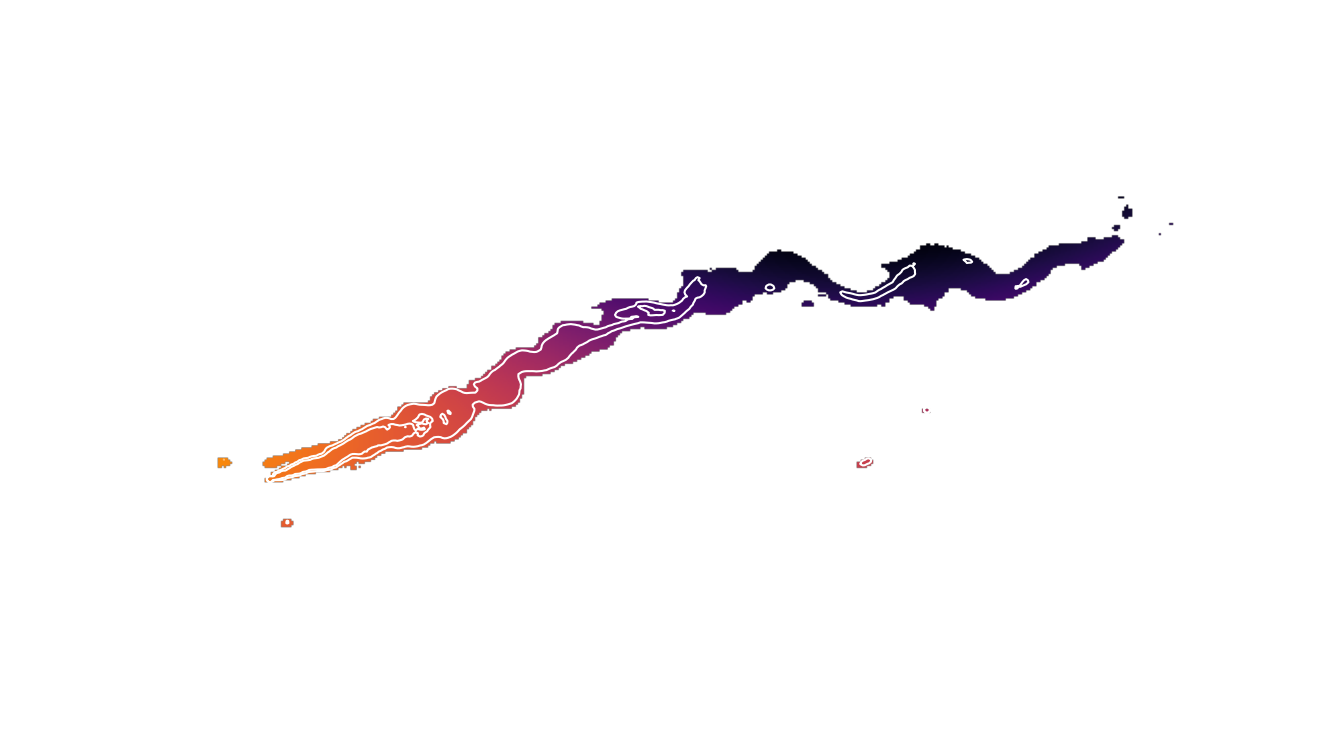

In [12]:
mdl = sky_mf.components[2]
smp = samples_mf

sky_ref = smp.mean(mdl.ref_freq_model) * CONV_FACTOR

alpha = smp.mean(mdl.spectral_index)
alpha = np.where(sky_ref > mmin, alpha-2, np.nan)

contours = {'array': sky_ref, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.5}

print('plotting ...')
plot_arrays(
    sky_ref, 
    norm='log',
    vmin=mmin,
    vmax=mmax,
    dpi=300,
    **plot_dict,
)
plot_arrays(
    alpha, 
    norm='linear',
    vmin=amin,
    vmax=amax,
    dpi=300, 
    contour=contours,
    **plot_dict,
)